## Introduction
Greetings from the Kaggle bot! This is an automatically-generated kernel with starter code demonstrating how to read in the data and begin exploring. If you're inspired to dig deeper, click the blue "Fork Notebook" button at the top of this kernel to begin editing.

## Exploratory Analysis
To begin this exploratory analysis, first import libraries and define functions for plotting the data using `matplotlib`. Depending on the data, not all plots will be made. (Hey, I'm just a simple kerneling bot, not a Kaggle Competitions Grandmaster!)

In [2]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


There is 1 csv file in the current version of the dataset:


In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


The next hidden code cells define functions for plotting data. Click on the "Code" button in the published kernel to reveal the hidden code.

In [4]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()


In [5]:
# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = df.dataframeName
    df = df.dropna('columns') # drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()


In [6]:
# Scatter and density plots
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular
    df = df.dropna('columns')
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()


Now you're ready to read in the data and use the plotting functions to visualize the data.

### Let's check 1st file: /kaggle/input/2012-2013-data-with-predictions-4-final.csv

In [7]:
nRowsRead = 1000 # specify 'None' if want to read whole file
# 2012-2013-data-with-predictions-4-final.csv may have more rows in reality, but we are only loading/previewing the first 1000 rows
df1 = pd.read_csv(r"C:\Users\sunil\Downloads\btech-project\2012-2013-data-with-predictions-4-final.csv", delimiter=',', nrows = nRowsRead)
df1.dataframeName = '2012-2013-data-with-predictions-4-final.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 35 columns


Let's take a quick look at what the data looks like:

In [8]:
df1.head(5)

,problem_log_id,skill,problem_id,user_id,assignment_id,assistment_id,start_time,end_time,problem_type,original,...,overlap_time,template_id,answer_id,answer_text,first_action,problemlogid,Average_confidence(FRUSTRATED),Average_confidence(CONFUSED),Average_confidence(CONCENTRATING),Average_confidence(BORED)
0,137792159,NaN,557460,61394,565736,341511,2012-09-28 15:11:27,2012-09-28 15:11:36.856,choose_1,1,...,9852,341511,NaN,she,0,137792159,0.361323,0.0,0.336529,0.000000
1,138083797,Rounding,365981,61394,573819,204043,2012-10-09 11:01:52,2012-10-09 11:02:13.182,algebra,1,...,21175,204043,NaN,74.29,0,138083797,0.361323,0.0,0.766925,0.000000
2,142332619,Multiplication and Division Integers,426415,61394,734130,247525,2013-03-07 10:53:20,2013-03-07 10:53:28.661,algebra,1,...,8645,247525,NaN,00,0,142332619,0.361323,0.0,0.766925,0.442968
3,145939397,Proportion,86686,61394,821352,48081,2013-08-20 19:54:56,2013-08-20 19:55:21.753,algebra,1,...,25728,46362,NaN,3.8,0,145939397,0.775000,0.0,0.766925,0.912281
4,137111284,NaN,399669,76592,557216,227869,2012-09-10 17:20:10,2012-09-10 17:24:56.579,choose_1,1,...,286578,227869,NaN,C (wr - 1)(wr + 1),0,137111284,0.361323,0.0,0.766925,0.000000


Distribution graphs (histogram/bar graph) of sampled columns:

In [9]:
plotPerColumnDistribution(df1, 10, 5)

ValueError: Number of rows must be a positive integer, not 3.2

<Figure size 2400x2048 with 0 Axes>

Correlation matrix:

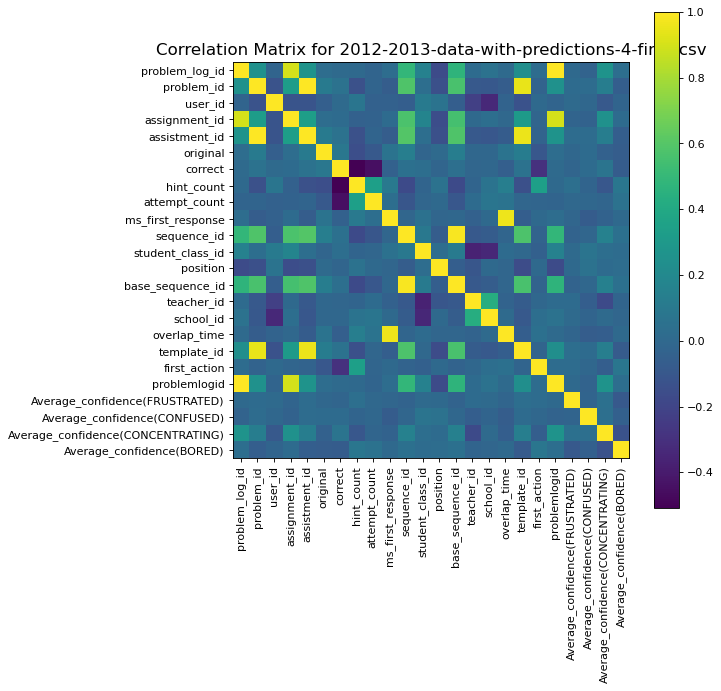

In [ ]:
plotCorrelationMatrix(df1, 8)

Scatter and density plots:

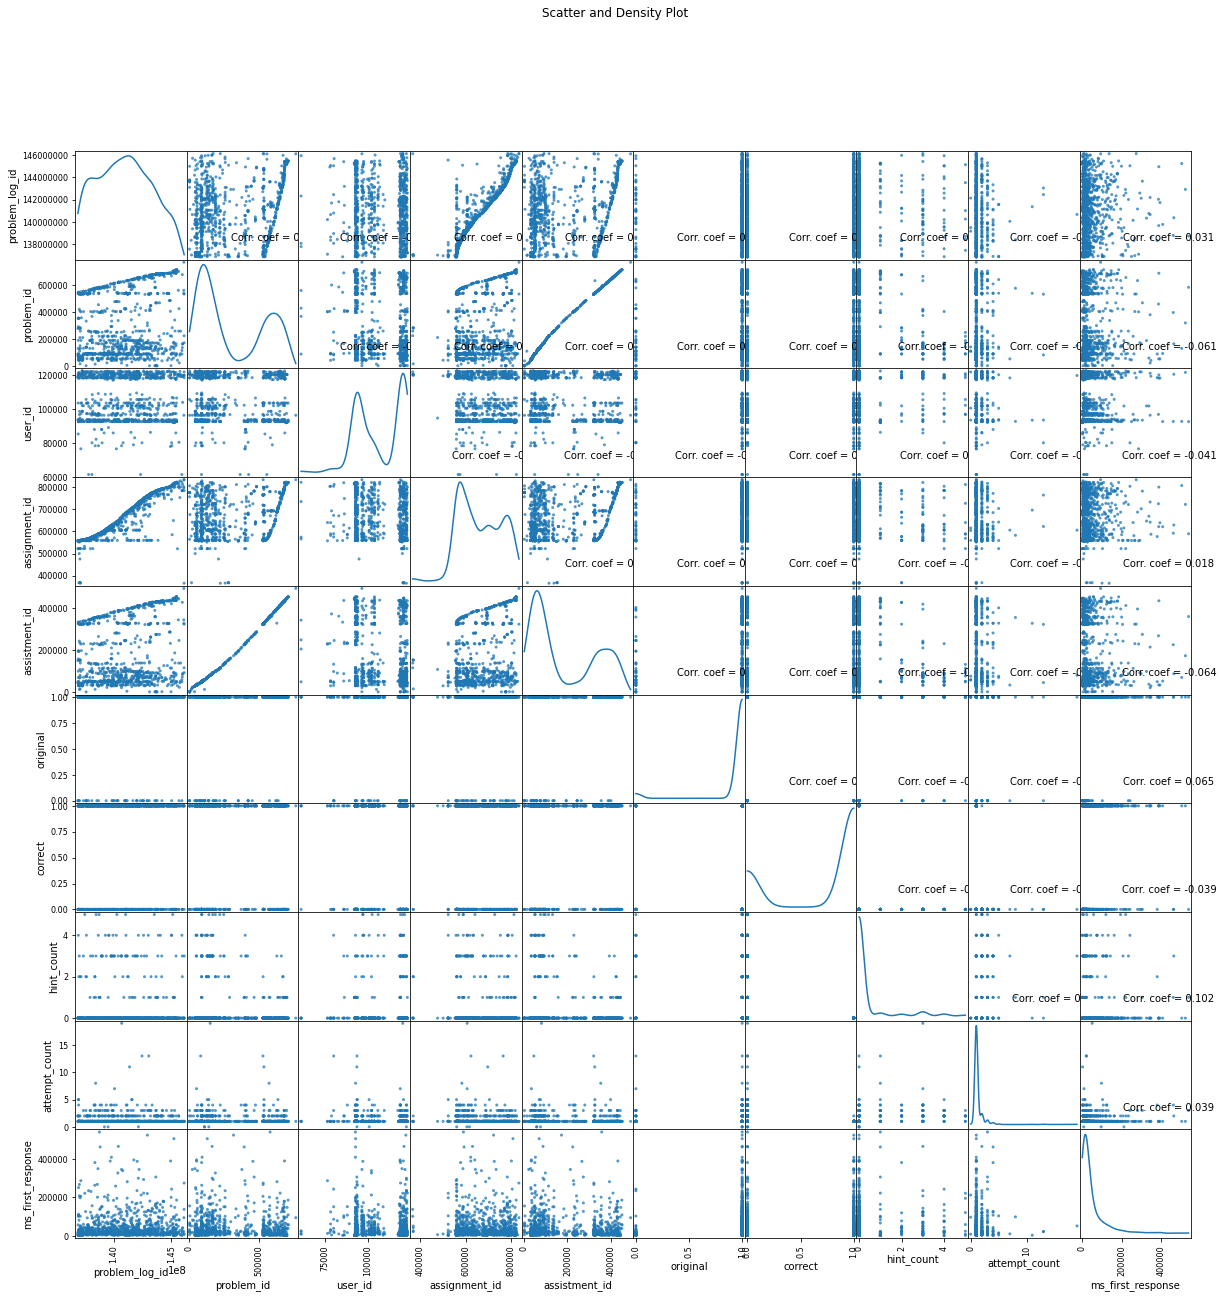

In [ ]:
plotScatterMatrix(df1, 20, 10)

## Conclusion
This concludes your starter analysis! To go forward from here, click the blue "Fork Notebook" button at the top of this kernel. This will create a copy of the code and environment for you to edit. Delete, modify, and add code as you please. Happy Kaggling!

# Part 2: Rigorous Model Comparison (DARS, DARS+, Glicko-2, and Elo)

In the DARS research track, we seek to evaluate the **Dynamic Adaptive Rating System (DARS)** and its calibrated variant (**DARS+**) against standard online skill-tracking baselines on the real-world **ASSISTments 2012-2013 Dataset**.

The ASSISTments dataset has over 6.1 million rows and contains key learner metrics:
- `correct`: binary correctness (target).
- `overlap_time`: response time in milliseconds.
- `hint_count`: count of hints requested.
- `user_id`: student ID.
- `problem_id`: question ID.

### Mapping ASSISTments to DARS Features
We map these features to the core DARS update equations:
1. **Expected success ($E$):** standard Elo expected probability between student rating $R_i$ and problem difficulty $R_j$:
   $$E = \frac{1}{1 + 10^{(R_j - R_i)/400}}$$
2. **Continuous Performance Quality ($P(q)$):**
   - If correct ($S = 1$): $P(q) = w_\tau \tau(q) + w_h (1 - H(q))$
     - $\tau(q) = e^{-\text{response\_time} / 30000}$ (time efficiency decaying with a half-life of 20 seconds).
     - $H(q) = \min(1.0, \text{hint\_count} / 5.0)$ (hint penalty).
     - $w_\tau = 0.8$ and $w_h = 0.2$ are feature weights.
   - If incorrect ($S = 0$): $P(q) = 0.0$.
3. **Streak and Momentum Multiplier ($\phi(k)$):**
   - Correct or incorrect streak $\ge 3$ multiplies learning rate by 1.2 to adapt rapidly.
4. **Dynamic uncertainty-decaying K-factor:**
   - $K$ decays with practice count: $K_s = \max(8.0, 32.0 / (1.0 + 0.01 \times n_i))$.

### Baseline Models
We compare the following:
- **Static Start:** Global correctness mean (no skill learning).
- **Fixed Elo (K=32):** Standard online Elo update for student and joint item ratings.
- **Glicko-2:** Dynamic student tracking incorporating rating deviation (uncertainty) per attempt.
- **DARS:** Raw Elo expectations using dynamic DARS ratings.
- **DARS+ Calibrated:** A Logistic Regression layer trained on a 70% student split, using pre-answer features: DARS logit, streak, time efficiency, hint penalty, and rating gap. Evaluated on the 30% held-out test students.


In [ ]:
# RUN ONLINE SIMULATION ON ALL 6 MILLION ROWS
import pandas as pd
import numpy as np
import math
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, accuracy_score

start_time = time.time()
csv_path = r'C:\Users\sunil\Downloads\btech-project\2012-2013-data-with-predictions-4-final.csv'

print("Loading essential columns...")
cols = ['user_id', 'problem_id', 'correct', 'overlap_time', 'start_time', 'hint_count', 'attempt_count', 'assignment_id']
df = pd.read_csv(csv_path, usecols=cols)
print(f"Loaded {len(df):,} rows.")

print("Cleaning and sorting chronologically...")
df = df[df['correct'].isin([0, 1])].copy()
df['correct'] = df['correct'].astype(int)
df['overlap_time'] = pd.to_numeric(df['overlap_time'], errors='coerce').fillna(22000.0)
df['hint_count'] = pd.to_numeric(df['hint_count'], errors='coerce').fillna(0).astype(int)
df['attempt_count'] = pd.to_numeric(df['attempt_count'], errors='coerce').fillna(1).astype(int)
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df = df.dropna(subset=['start_time', 'user_id', 'problem_id']).copy()
df = df.sort_values('start_time').reset_index(drop=True)

# Splits by Student
unique_users = df['user_id'].unique()
np.random.seed(2026)
np.random.shuffle(unique_users)
train_user_count = int(0.70 * len(unique_users))
train_users = set(unique_users[:train_user_count])
df['split'] = np.where(df['user_id'].isin(train_users), 'train', 'test')

# Helper formulas
def elo_expected(student_rating, problem_difficulty):
    return 1.0 / (1.0 + 10.0 ** ((problem_difficulty - student_rating) / 400.0))

def clip_prob(p):
    return np.clip(p, 1e-6, 1.0 - 1e-6)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower = bin_edges[i]
        bin_upper = bin_edges[i+1]
        in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if i == n_bins - 1:
            in_bin = in_bin | (y_prob == bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

# Glicko-2 Helper
def glicko2_g(phi):
    return 1.0 / math.sqrt(1.0 + 3.0 * (phi ** 2) / (math.pi ** 2))

def glicko2_expected(mu, opp_mu, opp_phi):
    return 1.0 / (1.0 + math.exp(-glicko2_g(opp_phi) * (mu - opp_mu)))

print("Running Joint Online Rating Simulation over 6.04 Million Rows...")
elo_students = {}
elo_problems = {}
dars_students = {}
dars_problems = {}
student_streaks = {}
student_attempts = {}
glicko_mu = {}
glicko_phi = {}

elo_probs = np.zeros(len(df))
glicko_probs = np.zeros(len(df))
dars_probs = np.zeros(len(df))
rating_gaps = np.zeros(len(df))
streak_befores = np.zeros(len(df))
time_efficiencies = np.zeros(len(df))
hint_penalties = np.zeros(len(df))

for idx, row in enumerate(df.itertuples()):
    uid = row.user_id
    pid = row.problem_id
    s = row.correct
    overlap = row.overlap_time
    hints = row.hint_count
    
    # 1. Elo
    r_s = elo_students.get(uid, 1500.0)
    d_p = elo_problems.get(pid, 1500.0)
    e_elo = elo_expected(r_s, d_p)
    elo_probs[idx] = e_elo
    elo_students[uid] = r_s + 32.0 * (s - e_elo)
    elo_problems[pid] = d_p - 8.0 * (s - e_elo)
    
    # 2. Glicko-2
    mu_s = glicko_mu.get(uid, 0.0)
    phi_s = glicko_phi.get(uid, 2.0148)
    mu_p = glicko_mu.get(pid, 0.0)
    phi_p = 0.4605
    e_glicko = glicko2_expected(mu_s, mu_p, phi_p)
    glicko_probs[idx] = e_glicko
    g_phi = glicko2_g(phi_p)
    variance_inv = (g_phi ** 2) * e_glicko * (1 - e_glicko)
    if variance_inv > 0:
        d_mu = (phi_s ** 2) / (1.0 + (phi_s ** 2) * variance_inv) * g_phi * (s - e_glicko)
        glicko_mu[uid] = mu_s + d_mu
        phi_s_new = math.sqrt(phi_s ** 2 + 0.001)
        glicko_phi[uid] = max(0.2, min(2.0148, phi_s_new - 0.05))
        
    # 3. DARS
    r_dars = dars_students.get(uid, 1500.0)
    d_dars = dars_problems.get(pid, 1500.0)
    streak = student_streaks.get(uid, 0)
    attempts = student_attempts.get(uid, 0)
    
    e_dars = elo_expected(r_dars, d_dars)
    dars_probs[idx] = e_dars
    
    tau = math.exp(-overlap / 30000.0)
    h_pen = min(1.0, hints / 5.0)
    p_q = 0.8 * tau + 0.2 * (1.0 - h_pen) if s == 1 else 0.0
    phi_k = 1.2 if abs(streak) >= 3 else 1.0
    k_s = max(8.0, 32.0 / (1.0 + 0.01 * attempts))
    
    dars_students[uid] = r_dars + k_s * phi_k * (p_q - e_dars)
    dars_problems[pid] = d_dars - 8.0 * (s - e_dars)
    
    rating_gaps[idx] = r_dars - d_dars
    streak_befores[idx] = streak
    time_efficiencies[idx] = tau
    hint_penalties[idx] = h_pen
    
    student_attempts[uid] = attempts + 1
    if s == 1:
        student_streaks[uid] = streak + 1 if streak >= 0 else 1
    else:
        student_streaks[uid] = streak - 1 if streak <= 0 else -1

print("Simulation finished. Fitting DARS+ Calibrated Layer...")
df['elo_prob'] = elo_probs
df['glicko_prob'] = glicko_probs
df['dars_prob'] = dars_probs
df['rating_gap'] = rating_gaps
df['streak_before'] = streak_befores
df['time_efficiency'] = time_efficiencies
df['hint_penalty'] = hint_penalties

train_mask = df['split'] == 'train'
test_mask = df['split'] == 'test'

features_plus = ['dars_logit', 'rating_gap', 'streak_before', 'time_efficiency', 'hint_penalty']

# Construct logit feature
df['dars_logit'] = np.log(clip_prob(df['dars_prob']) / (1.0 - clip_prob(df['dars_prob'])))

X_train = df.loc[train_mask, features_plus]
X_test = df.loc[test_mask, features_plus]
y_train = df.loc[train_mask, 'correct'].values
y_test = df.loc[test_mask, 'correct'].values

clf = LogisticRegression(max_iter=1000, random_state=2026)
clf.fit(X_train, y_train)

df.loc[test_mask, 'dars_plus_prob'] = clf.predict_proba(X_test)[:, 1]
df.loc[test_mask, 'static_prob'] = y_train.mean()

print(f"DARS+ calibration complete. Evaluated on {test_mask.sum():,} held-out attempts.")


In [ ]:
# GENERATE BENCHMARK COMPARISON TABLE
test_df = df[df['split'] == 'test'].copy()
y_true = test_df['correct'].values

models = {
    'Static Start': 'static_prob',
    'Fixed Elo K=32': 'elo_prob',
    'Glicko-2': 'glicko_prob',
    'DARS': 'dars_prob',
    'DARS+ Calibrated': 'dars_plus_prob'
}

results = []
for name, col in models.items():
    p = test_df[col].values
    results.append({
        'Model': name,
        'Brier Score': brier_score_loss(y_true, p),
        'Log Loss': log_loss(y_true, clip_prob(p)),
        'Accuracy': accuracy_score(y_true, p >= 0.5),
        'ROC AUC': roc_auc_score(y_true, p),
        'ECE (10 bins)': expected_calibration_error(y_true, p)
    })

results_df = pd.DataFrame(results).sort_values('Brier Score')
display(results_df.round(4))


In [ ]:
# PLOT METRIC COMPARISON AND CALIBRATION CURVES
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Bar Chart of Model Metrics
model_names = results_df['Model'].values
auc_scores = results_df['ROC AUC'].values
brier_scores = results_df['Brier Score'].values
ece_scores = results_df['ECE (10 bins)'].values

x = np.arange(len(model_names))
width = 0.25

rects1 = axes[0].bar(x - width, auc_scores, width, label='ROC AUC', color='#2563EB')
rects2 = axes[0].bar(x, brier_scores, width, label='Brier Score', color='#E11D48')
rects3 = axes[0].bar(x + width, ece_scores, width, label='ECE', color='#16A34A')

axes[0].set_title('Predictive Metrics Comparison on ASSISTments', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=25, ha='right')
axes[0].set_ylim(0.0, 1.0)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# 2. Calibration Curve (Reliability Diagram)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='#64748B', label='Perfect Calibration')

for name, col in models.items():
    p = test_df[col].values
    prob_true, prob_pred = calibration_curve(y_true, p, n_bins=10)
    axes[1].plot(prob_pred, prob_true, marker='o', label=name, linewidth=2)

axes[1].set_title('Calibration Curves (Reliability Diagram)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Actual Correctness Rate')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
